# Multi-Model RTSP Object Detection
Runs **three models in parallel** on every frame:
- `coverall.pt` — CoverAll / NoCoverAll PPE detection
- `hardhat.pt` — Head / Helmet detection
- `yolo.pt` — 80-class COCO general detection

Each model gets its own box colour. Results are merged and drawn on a single annotated frame.

## 1. Install Dependencies

In [ ]:
!pip install "ultralytics>=8.3.100" opencv-python-headless torch torchvision "numpy<2.0" --quiet

## 2. Configuration — Edit These Values

In [1]:
# ── STREAM ────────────────────────────────────────────────────────────────────
RTSP_URL    = "rtsp://localhost:8554/webcam"   

# ── MODEL PATHS ───────────────────────────────────────────────────────────────
COVERALL_PT = "./trained_models/coverall.pt"
HARDHAT_PT  = "./trained_models/hardhat.pt"
YOLO_PT     = "./trained_models/yolo.pt"

# ── INFERENCE ─────────────────────────────────────────────────────────────────
CONF_THRESH = 0.40
IOU_THRESH  = 0.45
DEVICE      = "cpu"          # "cpu" | "cuda" | "mps"
MAX_FRAMES  = 0              # 0 = run until stopped

# ── PER-MODEL BOX COLOURS (BGR) ───────────────────────────────────────────────
MODEL_STYLES = {
    "coverall": {
        "color"     : (0, 200, 0),      # green
        "text_color": (0,   0, 0),
    },
    "hardhat": {
        "color"     : (0, 140, 255),    # orange
        "text_color": (0,   0, 0),
    },
    "yolo": {
        "color"     : (200, 0, 200),    # purple
        "text_color": (255, 255, 255),
    },
}

# ── ALERT CONFIG ──────────────────────────────────────────────────────────────
# Classes that trigger a console alert (add any class name from any model)
ALERT_CLASSES   = ["NoCoverALL", "head"]   # "head" = no helmet
ALERT_COOLDOWN  = 10   # seconds between repeated alerts per class

# ── DISPLAY ───────────────────────────────────────────────────────────────────
BOX_THICK   = 2
FONT_SCALE  = 0.55
FONT_THICK  = 1


## 3. Load All Three Models

In [2]:
from ultralytics import YOLO

models = {
    "coverall": YOLO(COVERALL_PT),
    "hardhat" : YOLO(HARDHAT_PT),
    "yolo"    : YOLO(YOLO_PT),
}

for name, m in models.items():
    m.to(DEVICE)
    print(f"{name:12s} loaded  |  classes: {list(m.names.values())}")


coverall     loaded  |  classes: ['CoverAll', 'NoCoverALL']
hardhat      loaded  |  classes: ['head', 'helmet']
yolo         loaded  |  classes: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothb

## 4. Draw & Alert Helpers

In [3]:
import cv2, datetime

last_alert = {}

def draw_all(frame, detections):
    """
    detections: list of (model_name, results) tuples.
    Draws boxes for every model with its own colour.
    Returns annotated frame and a legend surface.
    """
    for model_name, results in detections:
        style      = MODEL_STYLES[model_name]
        color      = style["color"]
        text_color = style["text_color"]

        for box in results[0].boxes:
            cls_id   = int(box.cls[0])
            conf     = float(box.conf[0])
            cls_name = models[model_name].names[cls_id]
            label    = f"[{model_name}] {cls_name} {conf:.2f}"

            x1, y1, x2, y2 = map(int, box.xyxy[0])

            # Bounding box
            cv2.rectangle(frame, (x1, y1), (x2, y2), color, BOX_THICK)

            # Label background
            (tw, th), baseline = cv2.getTextSize(
                label, cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE, FONT_THICK)
            label_y = max(y1, th + 6)
            cv2.rectangle(frame,
                          (x1, label_y - th - 4),
                          (x1 + tw + 4, label_y + baseline),
                          color, cv2.FILLED)
            cv2.putText(frame, label, (x1 + 2, label_y),
                        cv2.FONT_HERSHEY_SIMPLEX, FONT_SCALE,
                        text_color, FONT_THICK)

            # Alert check
            check_alert(cls_name, conf)

    return frame


def check_alert(cls_name, conf):
    if cls_name not in ALERT_CLASSES:
        return
    now  = datetime.datetime.now()
    last = last_alert.get(cls_name)
    if last is None or (now - last).seconds >= ALERT_COOLDOWN:
        last_alert[cls_name] = now
        print(f"\u26a0\ufe0f  ALERT [{now.strftime('%H:%M:%S')}]  "
              f"{cls_name}  (conf={conf:.2f})")


def draw_legend(frame):
    """Small colour-coded legend in the top-right corner."""
    h, w = frame.shape[:2]
    x0, y0, pad, line_h = w - 200, 10, 6, 22
    entries = [
        ("coverall.pt", MODEL_STYLES["coverall"]["color"]),
        ("hardhat.pt",  MODEL_STYLES["hardhat"]["color"]),
        ("yolo.pt",     MODEL_STYLES["yolo"]["color"]),
    ]
    box_h = pad * 2 + line_h * len(entries)
    cv2.rectangle(frame, (x0 - pad, y0), (w - pad, y0 + box_h),
                  (30, 30, 30), cv2.FILLED)
    for i, (label, color) in enumerate(entries):
        y = y0 + pad + i * line_h + line_h // 2
        cv2.rectangle(frame, (x0, y - 6), (x0 + 14, y + 6), color, cv2.FILLED)
        cv2.putText(frame, label, (x0 + 20, y + 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.42, (220, 220, 220), 1)
    return frame


## 5. Run Live Detection on RTSP Stream
> Press the **■ Stop** button or interrupt the kernel to end.

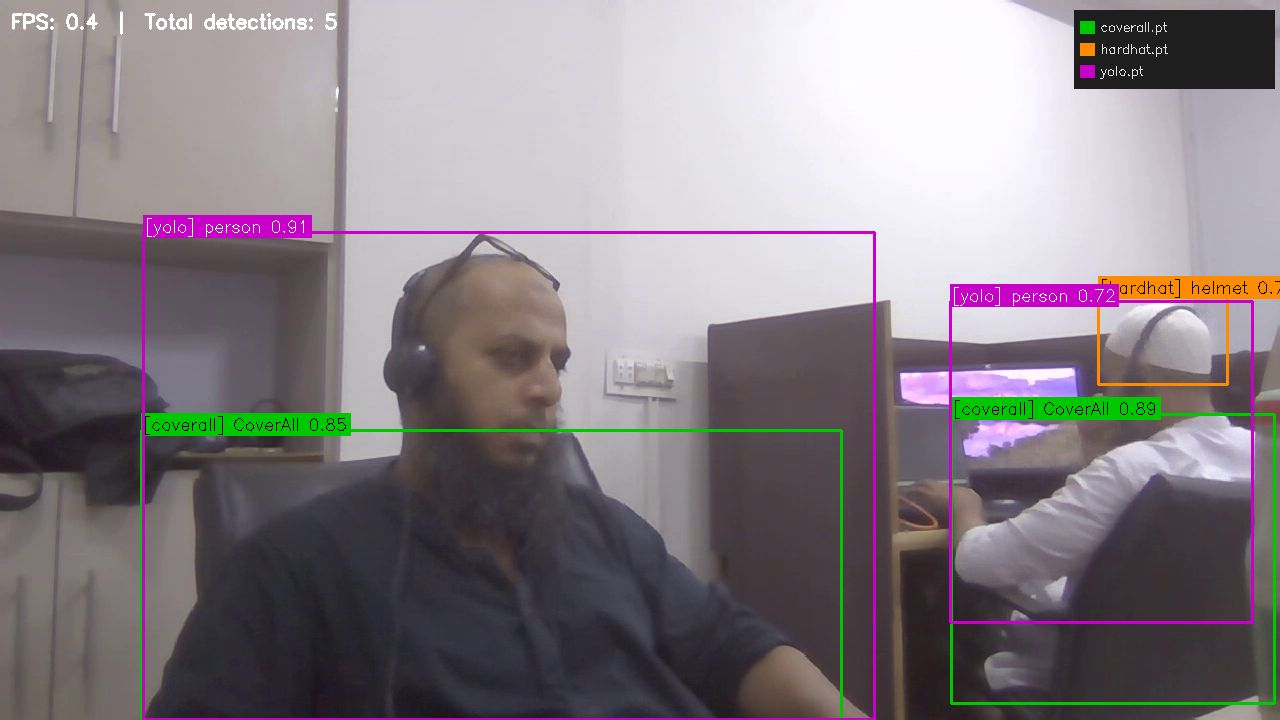

Stream ended or frame read failed.
Done  —  27 frames in 68.9s  (avg 0.4 FPS)


In [4]:
import cv2, time, io
import IPython.display as ipd
from IPython.display import clear_output
from PIL import Image

cap = cv2.VideoCapture(RTSP_URL)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open stream: {RTSP_URL}")

fps_src = cap.get(cv2.CAP_PROP_FPS) or 25
print(f"Stream opened  —  source FPS: {fps_src:.1f}")

frame_count = 0
t_start     = time.time()

try:
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Stream ended or frame read failed.")
            break

        # ── Run all three models ──────────────────────────────────────────────
        detections = [
            ("coverall", models["coverall"].predict(
                frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
            ("hardhat",  models["hardhat"].predict(
                frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
            ("yolo",     models["yolo"].predict(
                frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
        ]

        # ── Annotate ─────────────────────────────────────────────────────────
        annotated = draw_all(frame.copy(), detections)
        draw_legend(annotated)

        # ── FPS + detection count overlay ────────────────────────────────────
        frame_count += 1
        elapsed  = time.time() - t_start
        fps_live = frame_count / elapsed if elapsed > 0 else 0
        n_total  = sum(len(r[1][0].boxes) for r in detections)

        cv2.putText(annotated,
                    f"FPS: {fps_live:.1f}  |  Total detections: {n_total}",
                    (10, 28), cv2.FONT_HERSHEY_SIMPLEX, 0.65, (255, 255, 255), 2)

        # ── Display in notebook ──────────────────────────────────────────────
        rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
        buf = io.BytesIO()
        Image.fromarray(rgb).save(buf, format="JPEG", quality=80)
        clear_output(wait=True)
        ipd.display(ipd.Image(buf.getvalue()))

        if MAX_FRAMES and frame_count >= MAX_FRAMES:
            print(f"Reached MAX_FRAMES={MAX_FRAMES}. Stopping.")
            break

except KeyboardInterrupt:
    print("Interrupted.")
finally:
    cap.release()
    elapsed = time.time() - t_start
    print(f"Done  —  {frame_count} frames in {elapsed:.1f}s  "
          f"(avg {frame_count/elapsed:.1f} FPS)")


## 6. (Optional) Save Annotated Video to Disk

In [5]:
OUTPUT_VIDEO = "output_multi_model.mp4"
SAVE_FRAMES  = 300

cap = cv2.VideoCapture(RTSP_URL)
if not cap.isOpened():
    raise RuntimeError(f"Cannot open stream: {RTSP_URL}")

w   = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h   = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS) or 25

writer = cv2.VideoWriter(OUTPUT_VIDEO,
                         cv2.VideoWriter_fourcc(*"mp4v"),
                         fps, (w, h))

print(f"Recording {SAVE_FRAMES} frames → {OUTPUT_VIDEO}  ({w}×{h} @ {fps:.0f} FPS)")

for i in range(SAVE_FRAMES):
    ret, frame = cap.read()
    if not ret:
        break
    detections = [
        ("coverall", models["coverall"].predict(frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
        ("hardhat",  models["hardhat"].predict( frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
        ("yolo",     models["yolo"].predict(    frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
    ]
    annotated = draw_all(frame.copy(), detections)
    draw_legend(annotated)
    writer.write(annotated)
    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{SAVE_FRAMES} frames written…")

cap.release()
writer.release()
print(f"Saved: {OUTPUT_VIDEO}")


Recording 300 frames → output_multi_model.mp4  (1280×720 @ 30 FPS)
Saved: output_multi_model.mp4


## 7. (Optional) Single-Frame Test — No Stream Required

In [ ]:
TEST_IMAGE = "test.jpg"   # replace with any image path

import cv2, io
import IPython.display as ipd
from PIL import Image

frame = cv2.imread(TEST_IMAGE)

detections = [
    ("coverall", models["coverall"].predict(frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
    ("hardhat",  models["hardhat"].predict( frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
    ("yolo",     models["yolo"].predict(    frame, conf=CONF_THRESH, iou=IOU_THRESH, device=DEVICE, verbose=False)),
]

annotated = draw_all(frame.copy(), detections)
draw_legend(annotated)

rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)
buf = io.BytesIO()
Image.fromarray(rgb).save(buf, format="JPEG", quality=90)
ipd.display(ipd.Image(buf.getvalue()))

print("\nDetections per model:")
for model_name, results in detections:
    boxes = results[0].boxes
    print(f"  {model_name:12s}  {len(boxes)} detection(s)")
    for box in boxes:
        cls  = int(box.cls[0])
        conf = float(box.conf[0])
        print(f"    {models[model_name].names[cls]:25s}  conf={conf:.2f}  "
              f"box={list(map(int, box.xyxy[0]))}")


## 8. Model & Class Reference

| Model | File | Classes |
|---|---|---|
| Coverall detector | `coverall.pt` | `CoverAll`, `NoCoverALL` |
| Hardhat detector | `hardhat.pt` | `head` (no helmet), `helmet` |
| General YOLO | `yolo.pt` | 80 COCO classes (person, car, truck…) |

**Box colours:**
- 🟩 Green → coverall.pt
- 🟧 Orange → hardhat.pt
- 🟪 Purple → yolo.pt

**Alerts fire when:** `NoCoverALL` or `head` (bare head) is detected. Edit `ALERT_CLASSES` in cell 2 to add or remove triggers.

### Troubleshooting
| Problem | Fix |
|---|---|
| Unpickling error | Run cell 1 and restart kernel |
| NumPy ABI error | Pin `numpy<2.0` in cell 1 and restart |
| Low FPS with 3 models | Use `DEVICE="cuda"`, or filter `yolo.pt` to specific classes only |
| Too many YOLO boxes | Raise `CONF_THRESH` to 0.55+ or filter by class in `draw_all` |